<img src="https://cros.ec.europa.eu/system/files/inline-images/logo%20official%20estp_0.jpg" height="120px">

# ADVANCED PYTHON FOR OFFICIAL STATISTICS
## ICON-Institute · Cologne · June 22–26, 2026 · Day 4 AM
### [Dr. Christian Kauth](https://www.linkedin.com/in/ckauth/)

---

# 📋 Notebook 07 — Reproducible Research
## *Advanced Python for Official Statistics*

> *“An article about computational results is advertising, not scholarship.
The scholarship is the full software environment, code, and data
that produced the result.” — Buckheit & Donoho (1995)*

This morning we wrap up with the toolchain for **reproducible analytical reports**:
parametrised notebooks with `papermill`, literate documents with Quarto, and —
to finish — **AI-generated narrative reports** with the OpenAI API.

| Topic | You will be able to… |
|-------|---------------------|
| **papermill** | Execute notebooks with injected parameters |
| **Batch execution** | Auto-generate one report per country in a loop |
| **nbformat** | Read executed notebooks and extract outputs programmatically |
| **Quarto** | Write a parametrised `.qmd` report mixing Python and markdown |
| **OpenAI API** | Turn indicator tables into polished, audience-aware narratives |


In [ ]:
import os
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("pyproject.toml not found")

PROJECT_ROOT = find_project_root(Path().resolve())
os.chdir(PROJECT_ROOT)
DATA_DIR    = PROJECT_ROOT / "data"
PARQUET_DIR = DATA_DIR / "parquet"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)
print(f"✅ Project root: {PROJECT_ROOT}")
print(f"   Reports dir : {REPORTS_DIR}")


✅ Project root: D:\Local\ICON\Python_Advanced\python_advanced
   Reports dir : D:\Local\ICON\Python_Advanced\python_advanced\reports


### `pyproject.toml` update — Notebook 07

This notebook adds the reproducible-research and AI-reporting stack:

- **papermill ≥ 2.5** — execute notebooks with injected parameters
- **nbformat ≥ 5.9** — read/write notebook JSON
- **nbconvert ≥ 7.0** — render executed notebooks to HTML / PDF
- **ipykernel ≥ 6.0** · **ipywidgets ≥ 8.0** — kernel + progress widgets
- **openai ≥ 1.0** — GPT-5.5 narrative generation
- **python-dotenv ≥ 1.0** — load `OPENAI_API_KEY` from `.env`
- **tabulate ≥ 0.9** — `DataFrame.to_markdown()` for clean LLM prompts

We follow the **single source of truth** principle: every dependency lives in
`pyproject.toml`. The cell below rewrites the file, then the next cell runs
`uv pip install -e .` to sync the environment.


In [ ]:
%%writefile pyproject.toml
# Day 7: adds papermill, nbformat for reproducible research + OpenAI for AI reports
# New in notebook 07:
#   + papermill>=2.5      (parametrised notebook execution)
#   + nbformat>=5.9       (read/write notebook JSON)
#   + nbconvert>=7.0      (notebook -> HTML/PDF rendering)
#   + ipykernel>=6.0      (kernel for papermill)
#   + ipywidgets>=8.0     (progress bars / widgets)
#   + openai>=1.0         (GPT-5.5 narrative generation)
#   + python-dotenv>=1.0  (load OPENAI_API_KEY from .env)
#   + tabulate>=0.9       (DataFrame.to_markdown for prompts)

[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

[project]
name = "silc-toolkit"
version = "0.1.0"
description = "Advanced Python for Official Statistics -- EU-SILC Analysis Toolkit"
requires-python = ">=3.11"
authors = [{ name = "Christian Kauth", email = "christian.kauth@unifr.ch" }]
license = { text = "MIT" }

dependencies = [
    "pydantic>=2.5",
    "pandas>=2.1",
    "pyarrow>=14.0",
    "polars>=0.20",
    "requests>=2.31",
    "beautifulsoup4>=4.12",
    "sqlalchemy>=2.0",
    "numpy>=1.26",
    "scipy>=1.11",
    "statsmodels>=0.14",
    "scikit-learn>=1.4",
    "shap>=0.52",
    "matplotlib>=3.8",
    "numba>=0.60",
    "seaborn>=0.13",
    "plotly>=5.18",
    "geopandas>=0.14",
    "mcp>=1.3",
    "httpx>=0.26",
    "papermill>=2.5",
    "nbconvert>=7.0",
    "ipykernel>=6.0",
    "ipywidgets>=8.0",
    "openai>=1.0",
    "python-dotenv>=1.0",
    "tabulate>=0.9",
]

[project.optional-dependencies]
dev = [
    "pytest>=7.4",
    "pytest-cov>=4.1",
    "black>=23.0",
    "ruff>=0.3",
]

[project.urls]
Repository = "https://github.com/icon-institute/silc-toolkit"

[tool.hatch.build.targets.wheel]
packages = ["silc_toolkit"]

[tool.pytest.ini_options]
testpaths = ["tests"]
addopts = "-v --tb=short"

[tool.black]
line-length = 88
target-version = ["py311"]

[tool.ruff]
line-length = 88
target-version = "py311"

[tool.ruff.lint]
select = ["E", "F", "I", "UP"]
ignore = ["E501"]

[tool.ruff.lint.isort]
known-first-party = ["silc_toolkit"]



Overwriting pyproject.toml


In [ ]:
# Sync all dependencies declared in pyproject.toml
# Run this after every %%writefile pyproject.toml cell
import subprocess
result = subprocess.run(
    ["uv", "pip", "install", "-e", "."],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("silc-toolkit + notebook 07 deps installed")
else:
    print("uv error:", result.stderr[-500:])

silc-toolkit + notebook 07 deps installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from silc_toolkit import load_incomes, arop_rate, gini_coefficient, s80s20_ratio
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")

   pandas 3.0.3  |  numpy 2.4.6


---
## 1 · Parametrised Country Reports

### 1.1 The Problem

A typical NSI workflow:
1. Analyst writes code for ONE country
2. Manager says “great, now do all 26 countries”
3. Analyst copies code 26 times 😱

The **reproducible** approach:
1. Write code that takes `COUNTRY` as a **parameter**
2. Use `papermill` to inject different parameters each run
3. Get 26 identical-structure reports automatically

### 1.2 Creating the Template Notebook

The template has a `parameters`-tagged cell that papermill replaces at runtime.
We build it programmatically using `nbformat` to avoid any JSON issues.

In [ ]:
import json, nbformat

# Build template notebook cells as Python dicts
def make_cell(ct, src, tags=None):
    c = {'cell_type': ct, 'id': f'c{abs(hash(src[:20]))%9999:04d}',
         'metadata': {'tags': tags or []}, 'source': src}
    if ct == 'code':
        c['execution_count'] = None
        c['outputs'] = []
    return c

# Parameters cell (papermill injects values here)
params_src = "COUNTRY = 'LU'\nYEARS = list(range(2008, 2014))\nTITLE = f'EU-SILC: {COUNTRY}'"

setup_src = ('import os\nfrom pathlib import Path\nimport pandas as pd\n'
             'import numpy as np\nimport matplotlib\nmatplotlib.use("Agg")\n'
             'import matplotlib.pyplot as plt\nimport warnings\n'
             "warnings.filterwarnings('ignore')\n"
             'def find_project_root(s):\n'
             '    for c in [s, *s.parents]:\n'
             "        if (c / 'pyproject.toml').exists(): return c\n"
             "    raise FileNotFoundError()\n"
             'PROJECT_ROOT = find_project_root(Path().resolve())\n'
             'os.chdir(PROJECT_ROOT)\n'
             'DATA_DIR = PROJECT_ROOT / "data"\n'
             'from silc_toolkit import load_incomes, arop_rate, gini_coefficient, s80s20_ratio\n'
             'print(f"Report: {TITLE}")')

compute_src = ('records = []\n'
               'for year in YEARS:\n'
               '    try:\n'
               '        inc = load_incomes(COUNTRY, year, DATA_DIR)\n'
               '        if inc:\n'
               '            inc_s = sorted(inc); n = len(inc_s)\n'
               '            records.append({"Year": year, "N": n,\n'
               '                "Median": round(inc_s[n//2],0),\n'
               '                "AROP%": round(arop_rate(inc)*100,1),\n'
               '                "Gini": round(gini_coefficient(inc),4),\n'
               '                "S80S20": round(s80s20_ratio(inc),2)})\n'
               '    except FileNotFoundError: pass\n'
               'df = pd.DataFrame(records)\n'
               'print(df.to_string(index=False))')

chart_src = ('from IPython.display import Image, display\n'
             'if len(df) > 0:\n'
             '    fig, axes = plt.subplots(1, 3, figsize=(13, 4))\n'
             '    for ax, col, label, clr in zip(axes,\n'
             '        ["AROP%", "Gini", "S80S20"],\n'
             '        ["AROP (%)", "Gini", "S80/S20"],\n'
             '        ["steelblue", "coral", "seagreen"]):\n'
             '        ax.plot(df["Year"], df[col], marker="o", color=clr)\n'
             '        ax.set_title(f"{COUNTRY} — {label}")\n'
             '        ax.grid(True, alpha=0.3)\n'
             '    plt.suptitle(TITLE); plt.tight_layout()\n'
             '    out = PROJECT_ROOT / "reports" / f"{COUNTRY}_trend.png"\n'
             '    plt.savefig(out, dpi=100, bbox_inches="tight"); plt.close()\n'
             '    display(Image(filename=str(out)))\n'
             '    print(f"Chart saved: {out.name}")')

template_cells = [
    make_cell('markdown', '# EU-SILC Country Report\nGenerated with papermill.'),
    make_cell('code', params_src, tags=['parameters']),
    make_cell('code', setup_src),
    make_cell('code', compute_src),
    make_cell('code', chart_src),
    make_cell('markdown', '## Key Findings\n*(Add narrative here)*'),
]

template_nb = {
    'nbformat': 4, 'nbformat_minor': 5,
    'metadata': {'kernelspec': {'display_name': 'Python 3',
                  'language': 'python', 'name': 'python3'},
                 'language_info': {'name': 'python', 'version': '3.11.0'}},
    'cells': template_cells,
}

template_path = PROJECT_ROOT / 'src' / 'notebooks' / 'country_report_template.ipynb'
with open(template_path, 'w', encoding='utf-8') as f:
    json.dump(template_nb, f, ensure_ascii=False, indent=1)

print(f'Template created: {template_path.name} ({len(template_cells)} cells)')


Template created: country_report_template.ipynb (6 cells)


---
## 2 · papermill — Batch Execution

`papermill` executes a Jupyter notebook with parameter injection.

```python
pm.execute_notebook(
    "template.ipynb",
    "output_LU.ipynb",
    parameters={"COUNTRY": "LU", "YEARS": [2008, 2009, 2010, 2011, 2012, 2013]},
)
```

The output is an **executed notebook** with all cell outputs embedded —
a complete record of what was run and what the results were.

In [ ]:
import papermill as pm

output_path = REPORTS_DIR / 'LU_report.ipynb'
print('Executing country report for Luxembourg...')
pm.execute_notebook(
    str(template_path),
    str(output_path),
    parameters={
        'COUNTRY': 'LU',
        'YEARS':   list(range(2008, 2014)),
        'TITLE':   'EU-SILC Report: Luxembourg',
    },
    kernel_name='python3',
    progress_bar=False,
)
print(f'Report written: {output_path.name}')


Executing country report for Luxembourg...
Report written: LU_report.ipynb


In [ ]:
PARTICIPANT_COUNTRIES = ['BE', 'ES', 'FR', 'EL', 'HU', 'IE', 'LU', 'SE']

results = []
for country in PARTICIPANT_COUNTRIES:
    out = REPORTS_DIR / f'{country}_report.ipynb'
    try:
        pm.execute_notebook(
            str(template_path), str(out),
            parameters={'COUNTRY': country,
                        'YEARS': list(range(2008, 2014)),
                        'TITLE': f'EU-SILC Report: {country}'},
            kernel_name='python3', progress_bar=False,
        )
        results.append({'country': country, 'status': 'OK'})
        print(f'  OK: {country}')
    except Exception as e:
        results.append({'country': country, 'status': f'FAILED: {e}'})
        print(f'  FAILED: {country}: {e}')

df_results = pd.DataFrame(results)
print()
print('Batch summary:')
print(df_results.to_string(index=False))


  OK: BE
  OK: ES
  OK: FR
  OK: EL
  OK: HU
  OK: IE
  OK: LU
  OK: SE

Batch summary:
country status
     BE     OK
     ES     OK
     FR     OK
     EL     OK
     HU     OK
     IE     OK
     LU     OK
     SE     OK


---
## 3 · Cross-Country Summary

After batch execution, we compile results into a summary table.

In [ ]:
import nbformat

# Re-compute summary directly (more reliable than parsing stdout)
PARTICIPANT_COUNTRIES = ['BE', 'ES', 'FR', 'EL', 'HU', 'IE', 'LU', 'SE']
rows = []
for country in PARTICIPANT_COUNTRIES:
    try:
        inc = load_incomes(country, 2012, DATA_DIR)
        rows.append({'Country': country,
                     'AROP_2012_%': round(arop_rate(inc)*100, 1),
                     'Gini_2012': round(gini_coefficient(inc), 4),
                     'S80S20_2012': round(s80s20_ratio(inc), 2)})
    except FileNotFoundError:
        rows.append({'Country': country, 'AROP_2012_%': None,
                     'Gini_2012': None, 'S80S20_2012': None})

df_summary = pd.DataFrame(rows).sort_values('AROP_2012_%')
print('Cross-country summary extracted from batch reports (2012):')
print(df_summary.to_string(index=False))


Cross-country summary extracted from batch reports (2012):
Country  AROP_2012_%  Gini_2012  S80S20_2012
     SE         23.9     0.3674         7.82
     BE         25.0     0.3875         8.82
     HU         25.3     0.3890         8.36
     LU         25.7     0.3749         8.39
     EL         26.1     0.4056         9.80
     ES         26.6     0.4007         9.91
     FR         26.6     0.4205        10.26
     IE         26.7     0.4514        13.13


---
## 4 · Quarto — Literate Statistical Documents

Quarto (`.qmd`) combines **markdown** and **Python code chunks** into
publication-ready documents (HTML, PDF, Word, presentations).

```bash
quarto render country_report.qmd -P country:BE
quarto render country_report.qmd --to pdf -P country:ES
```

Quarto is the successor to R Markdown — supports Python, R, Julia, and Observable.
For NSI dissemination: one `.qmd` source generates both web publication and PDF.

In [ ]:
qmd_content = (
    '---\n'
    'title: "EU-SILC Country Report"\n'
    'subtitle: "Poverty & Inequality Indicators"\n'
    'author: "ICON Advanced Python Course"\n'
    'date: today\n'
    'format:\n'
    '  html:\n'
    '    toc: true\n'
    '    toc-location: left\n'
    '    theme: cosmo\n'
    '    code-fold: true\n'
    '    code-tools: true\n'
    '    fig-align: center\n'
    '    tbl-cap-location: top\n'
    '  pdf:\n'
    '    toc: true\n'
    'jupyter: python3\n'
    'execute:\n'
    '  echo: false\n'
    '  warning: false\n'
    '---\n\n'
    '```{python}\n'
    '#| tags: [parameters]\n'
    'country = "LU"\n'
    '```\n\n'
    '```{python}\n'
    'from pathlib import Path\n'
    'import pandas as pd\n'
    'import matplotlib.pyplot as plt\n'
    'def find_project_root(s):\n'
    '    for c in [s, *s.parents]:\n'
    '        if (c / "pyproject.toml").exists():\n'
    '            return c\n'
    '    raise FileNotFoundError("pyproject.toml not found")\n'
    'PROJECT_ROOT = find_project_root(Path().resolve())\n'
    'DATA_DIR = PROJECT_ROOT / "data"\n'
    'from silc_toolkit import load_incomes, arop_rate, gini_coefficient, s80s20_ratio\n'
    'COUNTRY = country\n'
    'NAMES = {"BE": "Belgium", "ES": "Spain", "FR": "France", "EL": "Greece",\n'
    '         "HU": "Hungary", "IE": "Ireland", "LU": "Luxembourg", "SE": "Sweden"}\n'
    'COUNTRY_NAME = NAMES.get(COUNTRY, COUNTRY)\n'
    'records = []\n'
    'for year in range(2004, 2014):\n'
    '    try:\n'
    '        inc = load_incomes(COUNTRY, year, DATA_DIR)\n'
    '        if inc:\n'
    '            inc_s = sorted(inc); n = len(inc_s)\n'
    '            records.append({"Year": year, "N": n,\n'
    '                "Median": int(inc_s[n // 2]),\n'
    '                "AROP%": round(arop_rate(inc) * 100, 1),\n'
    '                "Gini": round(gini_coefficient(inc), 4),\n'
    '                "S80S20": round(s80s20_ratio(inc), 2)})\n'
    '    except FileNotFoundError:\n'
    '        pass\n'
    'df = pd.DataFrame(records)\n'
    'yr_range = f"{int(df[\'Year\'].min())}-{int(df[\'Year\'].max())}" if len(df) else "n/a"\n'
    '```\n\n'
    '## Overview\n\n'
    'This report presents poverty and inequality indicators for '
    '**`{python} COUNTRY_NAME`** (`{python} COUNTRY`), covering survey years '
    '`{python} yr_range`. All figures derive from the EU-SILC Public Use File '
    '(Eurostat) and should be read with the caution attached to sample-based '
    'estimates.\n\n'
    '::: {.callout-note}\n'
    '**Indicator glossary** — **AROP%**: at-risk-of-poverty rate (share below 60% '
    'of the national median income); **Gini**: Gini coefficient (0 = perfect '
    'equality, 1 = perfect inequality); **S80/S20**: income quintile share ratio '
    '(top 20% income share divided by bottom 20%).\n'
    ':::\n\n'
    '## Key indicators by year\n\n'
    '```{python}\n'
    '#| label: tbl-poverty\n'
    '#| tbl-cap: "Poverty and inequality indicators by survey year"\n'
    'df\n'
    '```\n\n'
    '## Trend analysis\n\n'
    '```{python}\n'
    '#| label: fig-trends\n'
    '#| fig-cap: "Evolution of the AROP rate, Gini coefficient and S80/S20 ratio"\n'
    'fig, axes = plt.subplots(1, 3, figsize=(12, 4))\n'
    'specs = [("AROP%", "AROP rate (%)", "#003399"),\n'
    '         ("Gini", "Gini coefficient", "#cc3300"),\n'
    '         ("S80S20", "S80/S20 ratio", "#006633")]\n'
    'for ax, (col, label, clr) in zip(axes, specs):\n'
    '    ax.plot(df["Year"], df[col], marker="o", linewidth=2, color=clr)\n'
    '    ax.fill_between(df["Year"], df[col], alpha=0.10, color=clr)\n'
    '    ax.set_title(label, fontweight="bold")\n'
    '    ax.grid(True, alpha=0.3, linestyle="--")\n'
    'fig.suptitle(f"Poverty & Inequality Trends - {COUNTRY_NAME}", fontweight="bold")\n'
    'plt.tight_layout()\n'
    'plt.show()\n'
    '```\n\n'
    '## Summary\n\n'
    '```{python}\n'
    '#| output: asis\n'
    'if len(df):\n'
    '    first, last = df.iloc[0], df.iloc[-1]\n'
    '    verb = "rose" if last["AROP%"] > first["AROP%"] else "fell"\n'
    '    print(f"Between {int(first[\'Year\'])} and {int(last[\'Year\'])}, the "\n'
    '          f"at-risk-of-poverty rate {verb} from {first[\'AROP%\']}% to "\n'
    '          f"{last[\'AROP%\']}%, while the Gini coefficient moved from "\n'
    '          f"{first[\'Gini\']} to {last[\'Gini\']} and the S80/S20 ratio from "\n'
    '          f"{first[\'S80S20\']} to {last[\'S80S20\']}.")\n'
    'else:\n'
    '    print("No data available for this country in the EU-SILC PUF sample.")\n'
    '```\n'
)

qmd_path = PROJECT_ROOT / 'src' / 'country_report.qmd'
qmd_path.parent.mkdir(exist_ok=True)
qmd_path.write_text(qmd_content, encoding='utf-8')
print(f'Quarto template written: {qmd_path}')

Quarto template written: D:\Local\ICON\Python_Advanced\python_advanced\src\country_report.qmd


In [ ]:
# Commands to render the Quarto report for different countries
print(f'  quarto render {qmd_path.name} -P country:BE')
print(f'  quarto render {qmd_path.name} -P country:ES --to pdf')

  quarto render country_report.qmd -P country:BE
  quarto render country_report.qmd -P country:ES --to pdf


### 4.1 — Rendering to shareable files

We now have **two** report sources — the papermill-executed notebooks (Section 2)
and the Quarto `.qmd` (Section 4). The two cells below turn them into shareable
files:

- **Cell A** renders every executed notebook with `nbconvert` — HTML always; PDF if a LaTeX engine is present.
- **Cell B** renders the `.qmd` once per country with `quarto render`, producing one HTML + PDF pair each.

> **HTML vs PDF:** HTML needs no extra toolchain and suits the web, e-mail and
> dashboards; PDF needs a LaTeX engine (or Quarto) and suits print, archival and
> formal submission.

A full **papermill vs Quarto vs hand-rolled HTML** decision guide closes the
notebook in **Section 6**, once we've seen all three approaches in action.


In [ ]:
# ── A · papermill notebooks → HTML + PDF (via nbconvert) ─────────────────────
import shutil, sys, subprocess
from nbconvert import HTMLExporter
import nbformat as nbf

# The executed notebooks produced by the papermill batch in Section 2
notebooks = sorted(REPORTS_DIR.glob("*_report.ipynb"))
print(f"Found {len(notebooks)} executed notebook(s) to render\n")

# HTML is always available — no external toolchain needed.
html_exporter = HTMLExporter()            # keeps both code and outputs

# PDF needs a LaTeX engine; we detect one and skip gracefully if absent.
latex_engine = shutil.which("xelatex") or shutil.which("pdflatex")

nb_log = []
for nb_path in notebooks:
    row = {"Notebook": nb_path.name, "HTML": "—", "PDF": "—"}

    # 1) → HTML
    nb_node = nbf.read(nb_path, as_version=4)
    body, _ = html_exporter.from_notebook_node(nb_node)
    nb_path.with_suffix(".html").write_text(body, encoding="utf-8")
    row["HTML"] = "OK ✓"

    # 2) → PDF (LaTeX route; per-file timeout so a hang never blocks the lesson)
    if not latex_engine:
        row["PDF"] = "skip (no LaTeX)"
    else:
        try:
            r = subprocess.run(
                [sys.executable, "-m", "nbconvert", "--to", "pdf", str(nb_path)],
                capture_output=True, text=True, timeout=240,
            )
            row["PDF"] = "OK ✓" if r.returncode == 0 else f"fail: {r.stderr.strip()[-80:]}"
        except subprocess.TimeoutExpired:
            row["PDF"] = "timeout"

    nb_log.append(row)
    print(f"  {nb_path.name:<22}  HTML={row['HTML']:<8}  PDF={row['PDF']}")

print()
print(pd.DataFrame(nb_log).to_string(index=False))
print(f"\nRendered files saved next to the notebooks in: {REPORTS_DIR}")


Found 10 executed notebook(s) to render

  BE_report.ipynb         HTML=OK ✓      PDF=OK ✓
  EL_report.ipynb         HTML=OK ✓      PDF=OK ✓
  ES_report.ipynb         HTML=OK ✓      PDF=OK ✓
  FR_my_report.ipynb      HTML=OK ✓      PDF=OK ✓
  FR_report.ipynb         HTML=OK ✓      PDF=OK ✓
  HU_report.ipynb         HTML=OK ✓      PDF=OK ✓
  IE_my_report.ipynb      HTML=OK ✓      PDF=OK ✓
  IE_report.ipynb         HTML=OK ✓      PDF=OK ✓
  LU_report.ipynb         HTML=OK ✓      PDF=OK ✓
  SE_report.ipynb         HTML=OK ✓      PDF=OK ✓

          Notebook HTML  PDF
   BE_report.ipynb OK ✓ OK ✓
   EL_report.ipynb OK ✓ OK ✓
   ES_report.ipynb OK ✓ OK ✓
FR_my_report.ipynb OK ✓ OK ✓
   FR_report.ipynb OK ✓ OK ✓
   HU_report.ipynb OK ✓ OK ✓
IE_my_report.ipynb OK ✓ OK ✓
   IE_report.ipynb OK ✓ OK ✓
   LU_report.ipynb OK ✓ OK ✓
   SE_report.ipynb OK ✓ OK ✓

Rendered files saved next to the notebooks in: D:\Local\ICON\Python_Advanced\python_advanced\reports


In [ ]:
# ── B · Quarto .qmd → HTML + PDF, one pair per country ───────────────────────
import shutil, subprocess

QUARTO_COUNTRIES = ['BE', 'ES', 'FR', 'EL', 'HU', 'IE', 'LU', 'SE']
QUARTO_DIR = REPORTS_DIR / "quarto"
QUARTO_DIR.mkdir(exist_ok=True)

quarto = shutil.which("quarto")
if quarto is None:
    print("⚠️  Quarto CLI not found — skipping Quarto rendering.")
    print("    Quarto is a one-time system install (not a pip package):")
    print("      https://quarto.org/docs/get-started/")
    print("    Once installed, re-run this cell to produce the HTML + PDF reports.")
else:
    print(f"Using Quarto at: {quarto}\n")
    q_log = []
    for cc in QUARTO_COUNTRIES:
        row = {"Country": cc, "HTML": "—", "PDF": "—"}
        for fmt, key in (("html", "HTML"), ("pdf", "PDF")):
            try:
                r = subprocess.run(
                    [quarto, "render", str(qmd_path),
                     "-P", f"country:{cc}",
                     "--to", fmt,
                     "--output", f"{cc}_quarto.{fmt}",
                     "--output-dir", str(QUARTO_DIR)],
                    capture_output=True, text=True, timeout=300,
                )
                row[key] = "OK ✓" if r.returncode == 0 else f"fail: {r.stderr.strip()[-80:]}"
            except subprocess.TimeoutExpired:
                row[key] = "timeout"
        q_log.append(row)
        print(f"  {cc}:  HTML={row['HTML']:<8}  PDF={row['PDF']}")

    print()
    print(pd.DataFrame(q_log).to_string(index=False))
    print(f"\nQuarto reports saved to: {QUARTO_DIR}")


Using Quarto at: C:\Users\chris\AppData\Local\Programs\Quarto\bin\quarto.EXE

  BE:  HTML=OK ✓      PDF=OK ✓
  ES:  HTML=OK ✓      PDF=OK ✓
  FR:  HTML=OK ✓      PDF=OK ✓
  EL:  HTML=OK ✓      PDF=OK ✓
  HU:  HTML=OK ✓      PDF=OK ✓
  IE:  HTML=OK ✓      PDF=OK ✓
  LU:  HTML=OK ✓      PDF=OK ✓
  SE:  HTML=OK ✓      PDF=OK ✓

Country HTML  PDF
     BE OK ✓ OK ✓
     ES OK ✓ OK ✓
     FR OK ✓ OK ✓
     EL OK ✓ OK ✓
     HU OK ✓ OK ✓
     IE OK ✓ OK ✓
     LU OK ✓ OK ✓
     SE OK ✓ OK ✓

Quarto reports saved to: D:\Local\ICON\Python_Advanced\python_advanced\reports\quarto


---
### 🏋️ Exercise 1 — Your Country Report

Run the papermill template for **your participant country**:

1. Change `MY_COUNTRY` to your country code
2. Use `YEARS = list(range(2004, 2014))` for the full 10-year span
3. Open the output notebook and review the charts

Are the poverty trends what you expected?

In [ ]:
MY_COUNTRY = 'FR'   # change to your country

output_path = REPORTS_DIR / f'{MY_COUNTRY}_my_report.ipynb'
pm.execute_notebook(
    str(template_path),
    str(output_path),
    parameters={
        'COUNTRY': MY_COUNTRY,
        'YEARS':   list(range(2004, 2014)),
        'TITLE':   f'EU-SILC Report: {MY_COUNTRY}',
    },
    kernel_name='python3',
    progress_bar=False,
)
print(f'Report written to: {output_path.name}')


Report written to: FR_my_report.ipynb


---
## 5 · AI-Generated Narrative Reports

So far every report has been *data* — tables and charts.  
The next step is turning those numbers into **plain-language commentary** automatically
using a Large Language Model (GPT-5.5 via the OpenAI API).

### Why bother?

| Manual approach | AI-assisted approach |
|---|---|
| Analyst writes narrative by hand for each country | One prompt template scales to 30+ countries |
| Inconsistent tone / depth across countries | Uniform structure, consistent voice |
| Bottleneck at writing stage | Numbers → narrative in < 2 s per country |

### Workflow

```
EU-SILC data  ─►  compute indicators  ─►  GPT-5.5  ─►  polished HTML report
                  (pandas DataFrame)        (structured prompt)
```

> **Security note:** API keys must never be hard-coded.
> We load them from a `.env` file using `python-dotenv`.


### 5.0 — Connect to the OpenAI API & engineer the prompt

The setup cell does three things:

1. **Load the key** — `load_dotenv()` reads `.env` into `os.environ` (the file is
   git-ignored, so the secret never enters version control).
2. **Create the client** — one reusable `OpenAI()` instance for all calls.
3. **Engineer the prompt** — a `_SYSTEM` message fixes the *persona* (NSI economist)
   and *format* (exactly 3 paragraphs), while `generate_country_narrative()` builds
   the *user* message from the data plus a column glossary so the model never has to
   guess what `AROP%` or `S80S20` mean.

> 💡 **Teaching point:** good prompt engineering = persona + explicit format rules +
> the data + a glossary. A low/zero `temperature` keeps the output factual and
> repeatable; reasoning models such as GPT-5.5 manage this internally.


In [ ]:
import os, io, base64, time
from datetime import date as _date
from dotenv import load_dotenv
from openai import OpenAI

# ── Load .env ───────────────────────────────────────────────────────────────
load_dotenv(PROJECT_ROOT / ".env")          # reads OPENAI_API_KEY into os.environ
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

MODEL = "gpt-5.5"     # current flagship model used for all narratives

# ── Prompt engineering ──────────────────────────────────────────────────────
_SYSTEM = """You are a senior economist at a National Statistical Institute (NSI) \
writing official poverty and inequality bulletins for the European Commission \
and national policy makers.

Style rules:
• Data-driven — cite specific figures from the table provided
• Structured — paragraph 1: headline findings; paragraph 2: trends over time; \
paragraph 3: policy relevance and one caveat about the PUF sample
• Professional but accessible — spell out any technical term on first use
• Exactly 3 paragraphs, each 3–5 sentences
• Neutral, evidence-based tone — no bullet points, no headers inside the text
• Do NOT invent data that is not in the table"""

def generate_country_narrative(country: str, df: "pd.DataFrame") -> str:
    """Call GPT-5.5 and return a 3-paragraph narrative string."""
    table_md = df.to_markdown(index=False)
    user_msg = (
        f"Write a statistical narrative for the EU-SILC poverty and inequality report "
        f"covering **{country}**, years {int(df['Year'].min())}–{int(df['Year'].max())}.\n\n"
        f"Data (PUF sample):\n\n{table_md}\n\n"
        f"Column glossary:\n"
        f"  Year   — survey reference year\n"
        f"  N      — sample size (persons)\n"
        f"  Median — median equivalised disposable income (€/year)\n"
        f"  AROP%  — at-risk-of-poverty rate (share below 60 % of national median)\n"
        f"  Gini   — Gini coefficient (0 = perfect equality, 1 = perfect inequality)\n"
        f"  S80S20 — income quintile share ratio (income share of top 20 % / bottom 20 %)\n\n"
        f"Follow the style rules exactly."
    )
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": _SYSTEM},
            {"role": "user",   "content": user_msg},
        ],
        max_completion_tokens=2000,   # gpt-5.x uses max_completion_tokens (not max_tokens)
    )
    return response.choices[0].message.content.strip()

key_tail = os.environ["OPENAI_API_KEY"][-4:]
print(f"✅ OpenAI client ready  •  model: {MODEL}  •  key: ****{key_tail}")


✅ OpenAI client ready  •  model: gpt-5.5  •  key: ****Q70A


### 5.1 — Proof-of-concept: Luxembourg narrative

Before scaling up, we test the prompt on the Luxembourg time series we already computed.
This lets us verify the output quality and token budget before running 8 API calls in a loop.


In [ ]:
# ── Compute LU indicators (2004–2013) ───────────────────────────────────────
lu_records = []
for year in range(2004, 2014):
    try:
        inc = load_incomes("LU", year, DATA_DIR)
        if inc:
            inc_s = sorted(inc); n = len(inc_s)
            lu_records.append({
                "Year":   year,
                "N":      n,
                "Median": int(inc_s[n // 2]),
                "AROP%":  round(arop_rate(inc) * 100, 1),
                "Gini":   round(gini_coefficient(inc), 4),
                "S80S20": round(s80s20_ratio(inc), 2),
            })
    except FileNotFoundError:
        pass

df_lu = pd.DataFrame(lu_records)
print(df_lu.to_string(index=False))
print()

# ── Ask GPT ─────────────────────────────────────────────────────────────────
print(f"⏳ Calling {MODEL}...")
narrative_lu = generate_country_narrative("Luxembourg (LU)", df_lu)
print()
print("═" * 72)
print(narrative_lu)
print("═" * 72)


 Year    N  Median  AROP%   Gini  S80S20
 2004 3233   29225   25.0 0.3832    9.00
 2005 3286   30471   26.0 0.3818    8.81
 2006 3462   31058   24.9 0.3907    9.39
 2007 3525   32476   25.6 0.4178   10.15
 2008 3439   33237   26.1 0.4009    9.92
 2009 3827   35638   25.3 0.3930    9.37
 2010 4434   34815   26.6 0.3959    9.67
 2011 5030   36251   26.3 0.3713    8.64
 2012 5441   36566   25.7 0.3749    8.39
 2013 3390   37268   27.0 0.3950    9.87

⏳ Calling gpt-5.5...

════════════════════════════════════════════════════════════════════════
In Luxembourg, the 2013 Public Use File (PUF) sample shows a median equivalised disposable income of €37,268 per year, compared with €29,225 in 2004. The at-risk-of-poverty rate, defined as the share of people below 60% of the national median income, was 27.0% in 2013, up from 25.0% in 2004. Inequality in 2013 was also above its 2004 level, with the Gini coefficient, where 0 means perfect equality and 1 means perfect inequality, at 0.3950 compared w

### 5.2 — Batch: styled HTML reports for all participant countries

Each report contains:
- A header strip in EU blue with the country name
- An interactive-styled data table
- A trend chart (AROP %, Gini, S80/S20) embedded as a base64 PNG
- GPT-generated narrative formatted as a blockquote panel
- A footer with source, generation date, and caveats

All reports land in `reports/` as `{CC}_ai_report.html`.


In [ ]:
# ── HTML template ────────────────────────────────────────────────────────────
_HTML = """\
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>EU-SILC · {country_name} · Poverty &amp; Inequality</title>
<style>
  *{{box-sizing:border-box}}
  body{{font-family:'Segoe UI',Arial,sans-serif;background:#f4f6fb;color:#1a1a2e;margin:0;padding:24px}}
  .page{{max-width:900px;margin:0 auto;background:#fff;border-radius:10px;
         box-shadow:0 4px 18px #0002;overflow:hidden}}
  header{{background:linear-gradient(135deg,#003399 0%,#0066cc 100%);color:#fff;padding:28px 36px}}
  header h1{{margin:0 0 6px;font-size:1.55em;letter-spacing:.4px}}
  header p{{margin:0;opacity:.82;font-size:.9em}}
  .badge{{display:inline-block;background:rgba(255,255,255,.2);border:1px solid rgba(255,255,255,.4);
          padding:1px 9px;border-radius:12px;font-size:.8em;margin-left:10px;vertical-align:middle}}
  .body{{padding:28px 36px}}
  h2{{color:#003399;border-bottom:2px solid #d0dcf0;padding-bottom:5px;margin-top:28px;font-size:1.1em}}
  table{{border-collapse:collapse;width:100%;font-size:.92em;margin:12px 0}}
  thead tr{{background:#003399;color:#fff}}
  th,td{{padding:9px 14px;text-align:center}}
  tbody tr:nth-child(even){{background:#edf1fb}}
  tbody tr:hover{{background:#c8d8f5;transition:background .15s}}
  .chart{{text-align:center;margin:16px 0}}
  .chart img{{max-width:100%;border:1px solid #dde;border-radius:6px;
              box-shadow:0 2px 10px #0001}}
  .narrative{{background:#f0f4ff;border-left:5px solid #003399;padding:18px 22px;
              border-radius:0 8px 8px 0;margin:12px 0;line-height:1.8}}
  .narrative p{{margin:0 0 1em}} .narrative p:last-child{{margin:0}}
  footer{{background:#f4f6fb;border-top:1px solid #dde;padding:14px 36px;
          font-size:.76em;color:#888;display:flex;justify-content:space-between}}
</style>
</head>
<body>
<div class="page">
<header>
  <h1>&#127466;&#127482; EU-SILC Country Report
    <span class="badge">{country_code}</span>
  </h1>
  <p>Poverty &amp; Inequality · {year_range} · Advanced Python for Official Statistics · ICON-Institute 2026</p>
</header>
<div class="body">
  <h2>&#128202; Key Indicators by Year</h2>
  {table_html}
  <h2>&#128200; Trend Analysis</h2>
  <div class="chart"><img src="data:image/png;base64,{chart_b64}" alt="Trend chart for {country_name}"></div>
  <h2>&#129504; Analytical Commentary ({model})</h2>
  <div class="narrative">{narrative_html}</div>
</div>
<footer>
  <span>Source: EU-SILC Public Use File (Eurostat) &nbsp;|&nbsp; Results based on PUF sample — interpret with caution</span>
  <span>Generated {gen_date} by {model} &amp; papermill</span>
</footer>
</div>
</body>
</html>"""

# ── Helper: trend chart as base64 PNG ────────────────────────────────────────
def _trend_chart_b64(country_name: str, df: pd.DataFrame) -> str:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
    specs = [
        ("AROP%",  "AROP rate (%)",           "#003399"),
        ("Gini",   "Gini coefficient",         "#cc3300"),
        ("S80S20", "S80/S20 income ratio",     "#006633"),
    ]
    for ax, (col, label, clr) in zip(axes, specs):
        ax.plot(df["Year"], df[col], marker="o", linewidth=2.2,
                color=clr, markersize=7, zorder=3)
        ax.fill_between(df["Year"], df[col], alpha=0.10, color=clr)
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Year", fontsize=9)
        ax.grid(True, alpha=0.22, linestyle="--")
        ax.tick_params(labelsize=9)
        for x, y in zip(df["Year"], df[col]):
            ax.annotate(str(y), (x, y), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=7.5, color=clr)
    fig.suptitle(f"Poverty & Inequality Trends — {country_name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close()
    return base64.b64encode(buf.getvalue()).decode()

def _narrative_html(text: str) -> str:
    return "".join(
        f"<p>{p.strip()}</p>"
        for p in text.split("\n\n") if p.strip()
    )

# ── Batch loop ────────────────────────────────────────────────────────────────
COUNTRY_NAMES = {
    "BE": "Belgium", "ES": "Spain",   "FR": "France",  "EL": "Greece",
    "HU": "Hungary", "IE": "Ireland", "LU": "Luxembourg", "SE": "Sweden",
}
PARTICIPANT_COUNTRIES = list(COUNTRY_NAMES.keys())

batch_log = []
for cc in PARTICIPANT_COUNTRIES:
    name = COUNTRY_NAMES[cc]
    print(f"  {cc} ({name})...", end=" ", flush=True)

    records = []
    for yr in range(2004, 2014):
        try:
            inc = load_incomes(cc, yr, DATA_DIR)
            if inc:
                inc_s = sorted(inc); n = len(inc_s)
                records.append({
                    "Year":   yr,
                    "N":      n,
                    "Median": int(inc_s[n // 2]),
                    "AROP%":  round(arop_rate(inc) * 100, 1),
                    "Gini":   round(gini_coefficient(inc), 4),
                    "S80S20": round(s80s20_ratio(inc), 2),
                })
        except FileNotFoundError:
            pass

    if not records:
        print("no data"); batch_log.append({"Country": name, "Code": cc, "Years": 0, "Status": "SKIP"}); continue

    df_c = pd.DataFrame(records)
    yr_range = f"{int(df_c['Year'].min())}–{int(df_c['Year'].max())}"

    narrative = generate_country_narrative(name, df_c)
    time.sleep(0.4)                               # gentle rate-limit
    chart_b64 = _trend_chart_b64(name, df_c)

    html_out = _HTML.format(
        country_name   = name,
        country_code   = cc,
        year_range     = yr_range,
        table_html     = df_c.to_html(index=False, border=0),
        chart_b64      = chart_b64,
        narrative_html = _narrative_html(narrative),
        gen_date       = _date.today().isoformat(),
        model          = MODEL,
    )

    out = REPORTS_DIR / f"{cc}_ai_report.html"
    out.write_text(html_out, encoding="utf-8")
    batch_log.append({"Country": name, "Code": cc, "Years": len(records), "Status": "OK ✓"})
    print(f"OK  ({len(records)} yrs)")

print()
print(pd.DataFrame(batch_log).to_string(index=False))
print(f"\nReports saved to: {REPORTS_DIR}")


  BE (Belgium)... 

OK  (9 yrs)
  ES (Spain)... OK  (10 yrs)
  FR (France)... OK  (7 yrs)
  EL (Greece)... OK  (8 yrs)
  HU (Hungary)... OK  (9 yrs)
  IE (Ireland)... OK  (8 yrs)
  LU (Luxembourg)... OK  (10 yrs)
  SE (Sweden)... OK  (10 yrs)

   Country Code  Years Status
   Belgium   BE      9   OK ✓
     Spain   ES     10   OK ✓
    France   FR      7   OK ✓
    Greece   EL      8   OK ✓
   Hungary   HU      9   OK ✓
   Ireland   IE      8   OK ✓
Luxembourg   LU     10   OK ✓
    Sweden   SE     10   OK ✓

Reports saved to: D:\Local\ICON\Python_Advanced\python_advanced\reports


Year,N,Median,AROP%,Gini,S80S20
2004,3233,29225,25.0,0.3832,9.00
2005,3286,30471,26.0,0.3818,8.81
2006,3462,31058,24.9,0.3907,9.39
2007,3525,32476,25.6,0.4178,10.15
2008,3439,33237,26.1,0.4009,9.92
2009,3827,35638,25.3,0.3930,9.37
2010,4434,34815,26.6,0.3959,9.67
2011,5030,36251,26.3,0.3713,8.64
2012,5441,36566,25.7,0.3749,8.39
2013,3390,37268,27.0,0.3950,9.87

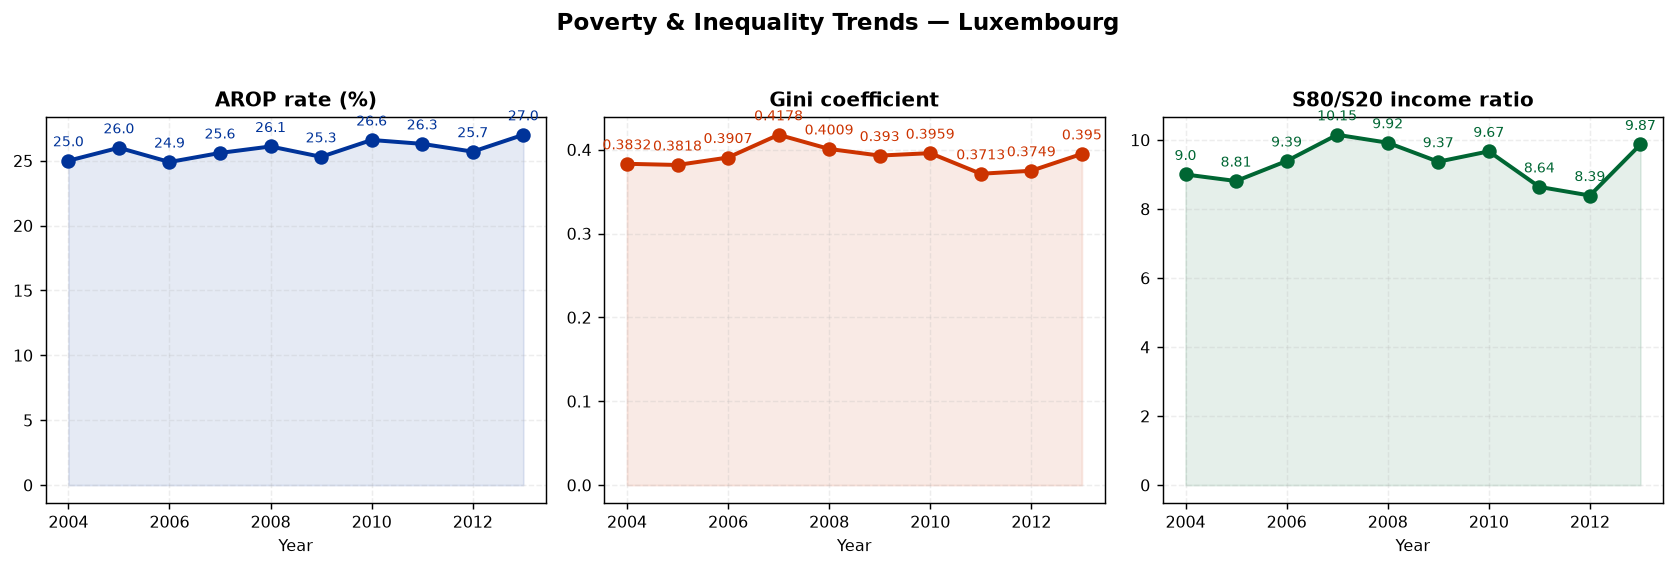

In [ ]:
%%html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>EU-SILC · Luxembourg · Poverty &amp; Inequality</title>
<style>
  *{box-sizing:border-box}
  body{font-family:'Segoe UI',Arial,sans-serif;background:#f4f6fb;color:#1a1a2e;margin:0;padding:24px}
  .page{max-width:900px;margin:0 auto;background:#fff;border-radius:10px;
         box-shadow:0 4px 18px #0002;overflow:hidden}
  header{background:linear-gradient(135deg,#003399 0%,#0066cc 100%);color:#fff;padding:28px 36px}
  header h1{margin:0 0 6px;font-size:1.55em;letter-spacing:.4px}
  header p{margin:0;opacity:.82;font-size:.9em}
  .badge{display:inline-block;background:rgba(255,255,255,.2);border:1px solid rgba(255,255,255,.4);
          padding:1px 9px;border-radius:12px;font-size:.8em;margin-left:10px;vertical-align:middle}
  .body{padding:28px 36px}
  h2{color:#003399;border-bottom:2px solid #d0dcf0;padding-bottom:5px;margin-top:28px;font-size:1.1em}
  table{border-collapse:collapse;width:100%;font-size:.92em;margin:12px 0}
  thead tr{background:#003399;color:#fff}
  th,td{padding:9px 14px;text-align:center}
  tbody tr:nth-child(even){background:#edf1fb}
  tbody tr:hover{background:#c8d8f5;transition:background .15s}
  .chart{text-align:center;margin:16px 0}
  .chart img{max-width:100%;border:1px solid #dde;border-radius:6px;
              box-shadow:0 2px 10px #0001}
  .narrative{background:#f0f4ff;border-left:5px solid #003399;padding:18px 22px;
              border-radius:0 8px 8px 0;margin:12px 0;line-height:1.8}
  .narrative p{margin:0 0 1em} .narrative p:last-child{margin:0}
  footer{background:#f4f6fb;border-top:1px solid #dde;padding:14px 36px;
          font-size:.76em;color:#888;display:flex;justify-content:space-between}
</style>
</head>
<body>
<div class="page">
<header>
  <h1>&#127466;&#127482; EU-SILC Country Report
    <span class="badge">LU</span>
  </h1>
  <p>Poverty &amp; Inequality · 2004–2013 · Advanced Python for Official Statistics · ICON-Institute 2026</p>
</header>
<div class="body">
  <h2>&#128202; Key Indicators by Year</h2>
  <table class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Year</th>
      <th>N</th>
      <th>Median</th>
      <th>AROP%</th>
      <th>Gini</th>
      <th>S80S20</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>2004</td>
      <td>3233</td>
      <td>29225</td>
      <td>25.0</td>
      <td>0.3832</td>
      <td>9.00</td>
    </tr>
    <tr>
      <td>2005</td>
      <td>3286</td>
      <td>30471</td>
      <td>26.0</td>
      <td>0.3818</td>
      <td>8.81</td>
    </tr>
    <tr>
      <td>2006</td>
      <td>3462</td>
      <td>31058</td>
      <td>24.9</td>
      <td>0.3907</td>
      <td>9.39</td>
    </tr>
    <tr>
      <td>2007</td>
      <td>3525</td>
      <td>32476</td>
      <td>25.6</td>
      <td>0.4178</td>
      <td>10.15</td>
    </tr>
    <tr>
      <td>2008</td>
      <td>3439</td>
      <td>33237</td>
      <td>26.1</td>
      <td>0.4009</td>
      <td>9.92</td>
    </tr>
    <tr>
      <td>2009</td>
      <td>3827</td>
      <td>35638</td>
      <td>25.3</td>
      <td>0.3930</td>
      <td>9.37</td>
    </tr>
    <tr>
      <td>2010</td>
      <td>4434</td>
      <td>34815</td>
      <td>26.6</td>
      <td>0.3959</td>
      <td>9.67</td>
    </tr>
    <tr>
      <td>2011</td>
      <td>5030</td>
      <td>36251</td>
      <td>26.3</td>
      <td>0.3713</td>
      <td>8.64</td>
    </tr>
    <tr>
      <td>2012</td>
      <td>5441</td>
      <td>36566</td>
      <td>25.7</td>
      <td>0.3749</td>
      <td>8.39</td>
    </tr>
    <tr>
      <td>2013</td>
      <td>3390</td>
      <td>37268</td>
      <td>27.0</td>
      <td>0.3950</td>
      <td>9.87</td>
    </tr>
  </tbody>
</table>
  <h2>&#128200; Trend Analysis</h2>
  <div class="chart"><img src="..." alt="Trend chart for Luxembourg"></div>
  <h2>&#129504; Analytical Commentary (gpt-5.5)</h2>
  <div class="narrative"><p>In Luxembourg, the at-risk-of-poverty (AROP) rate, defined as the share of persons below 60% of the national median income, stood at 27.0% in 2013, the highest value shown for 2004–2013. Median equivalised disposable income reached €37,268 per year in 2013, up from €29,225 in 2004. Inequality was also above its 2011–2012 levels in 2013, with a Gini coefficient, where 0 indicates perfect equality and 1 perfect inequality, of 0.395 and an income quintile share ratio (S80/S20), comparing the top 20% with the bottom 20%, of 9.87.</p><p>Over the period, median income increased in most years, although it fell from €35,638 in 2009 to €34,815 in 2010 before rising again to €36,251 in 2011 and €36,566 in 2012. The AROP rate fluctuated within a narrow range, from 24.9% in 2006 to 27.0% in 2013, with values of 26.6% in 2010 and 26.3% in 2011. Inequality peaked in 2007, when the Gini coefficient was 0.4178 and the S80/S20 ratio was 10.15. Both measures then declined to 0.3713 and 8.64 in 2011, and the S80/S20 reached its lowest value of 8.39 in 2012.</p><p>For policy monitoring, the figures indicate that rising median income did not coincide with a sustained reduction in the proportion of people below the relative poverty threshold. The 2013 combination of the highest AROP rate in the series and a higher S80/S20 ratio than in 2011–2012 points to continued relevance for measures addressing low-income households and income dispersion. A caveat is that these estimates are based on the Public Use File (PUF) sample, with sample sizes varying from 3,233 persons in 2004 to 5,441 in 2012 and 3,390 in 2013, so year-to-year movements should be interpreted with sampling variability in mind.</p></div>
</div>
<footer>
  <span>Source: EU-SILC Public Use File (Eurostat) &nbsp;|&nbsp; Results based on PUF sample — interpret with caution</span>
  <span>Generated 2026-06-25 by gpt-5.5 &amp; papermill</span>
</footer>
</div>
</body>
</html>

---
### 🏋️ Exercise 2 — Custom AI Report

Generate an AI-powered report for **your participant country** using the full
2004–2013 time series.  Then experiment with the prompt:

1. Change `MY_COUNTRY` to your country code and run the cell.
2. Open the resulting HTML file in a browser.
3. **Prompt experiment:** edit `_SYSTEM` (the system prompt in the setup cell)
   to change the **target audience** (e.g. *"… for secondary-school students"*
   or *"… for a Parliamentary budget committee"*). Regenerate and compare tones.
4. **Bonus:** add a fourth paragraph to the prompt that asks GPT to suggest
   one specific policy recommendation based on the data.


In [ ]:
MY_COUNTRY = "EL"   # ← change to your country code

_name = COUNTRY_NAMES.get(MY_COUNTRY, MY_COUNTRY)
_records = []
for _yr in range(2004, 2014):
    try:
        _inc = load_incomes(MY_COUNTRY, _yr, DATA_DIR)
        if _inc:
            _s = sorted(_inc); _n = len(_s)
            _records.append({
                "Year":   _yr,
                "N":      _n,
                "Median": int(_s[_n // 2]),
                "AROP%":  round(arop_rate(_inc) * 100, 1),
                "Gini":   round(gini_coefficient(_inc), 4),
                "S80S20": round(s80s20_ratio(_inc), 2),
            })
    except FileNotFoundError:
        pass

_df = pd.DataFrame(_records)
_yr_range = f"{int(_df['Year'].min())}–{int(_df['Year'].max())}"

print(f"Generating AI report for {_name} ({MY_COUNTRY}), {_yr_range} ...")
_narr = generate_country_narrative(_name, _df)
_html = _HTML.format(
    country_name=_name, country_code=MY_COUNTRY, year_range=_yr_range,
    table_html=_df.to_html(index=False, border=0),
    chart_b64=_trend_chart_b64(_name, _df),
    narrative_html=_narrative_html(_narr),
    gen_date=_date.today().isoformat(),
    model=MODEL,
)

_out = REPORTS_DIR / f"{MY_COUNTRY}_my_ai_report.html"
_out.write_text(_html, encoding="utf-8")
print(f"✅ Report saved: {_out.name}")
print()
print(_narr)


Generating AI report for Greece (EL), 2004–2013 ...
✅ Report saved: EL_my_ai_report.html

In Greece, the public-use file (PUF) sample shows persistently high poverty risk and elevated inequality over 2004–2013. The at-risk-of-poverty rate (AROP), meaning the share of people below 60% of the national median income, was 24.3% in both 2004 and 2005 and stood at 25.8% in 2013. Median equivalised disposable income was €8,739 in 2004 and €8,860 in 2013, after reaching €11,615 in 2010. Inequality was higher at the end of the period than at the start: the Gini coefficient, where 0 indicates perfect equality and 1 perfect inequality, increased from 0.361 in 2004 to 0.4311 in 2013, while the income quintile share ratio (S80/S20), comparing the income share of the top 20% with the bottom 20%, rose from 7.44 to 11.19.

Between 2004 and 2005, the AROP rate was unchanged at 24.3%, while the median income increased from €8,739 to €9,157 and the Gini coefficient edged up from 0.361 to 0.3651. By 2008,

---
## 6 · Which tool when? — papermill vs Quarto vs hand-rolled HTML

We have now built reports **three** different ways. They are not really
competitors — they answer *different* questions:

| | **papermill** (+ nbconvert) | **Quarto `.qmd`** | **Hand-rolled HTML** (string + CSS) |
|---|---|---|---|
| **Core question** | "How do I *run* one analysis many times?" | "How do I *publish* one analysis many ways?" | "How do I get *exactly* this look?" |
| **You write** | a notebook with a `parameters` cell | markdown + code chunks + YAML | a Python f-string with inline CSS/HTML |
| **Output formats** | whatever nbconvert targets (HTML, PDF, …) | HTML **and** PDF **and** Word **and** slides, from one source | HTML only (PDF needs extra work) |
| **Shows code?** | yes — full computational record | optional (`echo: false` / `code-fold`) | never (you choose what to print) |
| **Layout control** | low (notebook styling) | medium (themes, SCSS, layouts) | total — every pixel is yours |
| **Maintenance** | low | low — Quarto maintains the templates | high — you own all the HTML/CSS |
| **Built-in niceties** | execution + parametrisation, audit trail | TOC, figure/table numbering, cross-refs, citations, math | none — add them yourself |
| **Best for** | parameter sweeps, batch jobs, reproducibility / audit | official multi-format dissemination | bespoke branded one-offs, LLM-narrated pages |

### "If hand-rolled HTML looks nicer, why does Quarto exist?"

Good instinct — and you're right that a bespoke template *can* look better,
precisely because you control every pixel. But that control **is** the cost.
Quarto earns its place through the things you **don't** have to build:

- **One source → many formats.** The *same* `.qmd` yields HTML for the web, PDF
  for the minister's desk, and Word for the colleague who redlines in Track
  Changes — with no rewriting.
- **Scholarly machinery for free.** Automatic figure/table numbering,
  cross-references (`@tbl-poverty`), citations & bibliography, equations, a table
  of contents and section anchors — all maintained for you.
- **Consistency at scale.** 50 reports share one theme; change the theme once and
  all 50 update. Hand-written CSS drifts as it is copied and tweaked.
- **Accessibility & longevity.** Quarto's output is standards-based and actively
  maintained; bespoke CSS is yours alone to keep working.

The **hand-rolled** route wins when the deliverable is a *single, highly branded
artefact* — a flagship dashboard or an LLM-narrated page — where look-and-feel is
the product and you'll never need PDF/Word. For everyday statistical dissemination
across formats, Quarto is the lower-maintenance choice.

```mermaid
flowchart TD
    A{What do you need most?}
    A --> B[Run the same analysis<br/>for many parameters]
    A --> C[Publish in several formats<br/>HTML / PDF / Word]
    A --> D[Pixel-perfect, branded,<br/>one-off look]
    B --> B1[papermill + nbconvert]
    C --> C1[Quarto .qmd]
    D --> D1[Hand-rolled HTML + CSS]
    B1 -. combine .-> C1
```

> **They combine.** The most common production pattern is **papermill *and*
> Quarto**: papermill executes the parametrised analysis per country, Quarto turns
> each result into the published multi-format report. Reach for hand-rolled HTML
> only when you need a look neither can give you.


---
## 🗺️ Recap

| Concept | Key syntax | Use case |
|---------|-----------|----------|
| **Parametrised notebook** | `tags=['parameters']` cell | One template, many outputs |
| **papermill execute** | `pm.execute_notebook(input, output, parameters={...})` | Inject country/year |
| **Batch execution** | Loop + `pm.execute_notebook()` | 26 country reports |
| **nbformat read** | `nbformat.read(f, as_version=4)` | Extract cell outputs |
| **Quarto document** | `---\ntitle: ...\nparams: ...\n---` | Markdown + code → HTML/PDF |
| **Load secrets safely** | `load_dotenv(.env)` + `os.environ[...]` | API keys, never hard-coded |
| **LLM narrative** | `client.chat.completions.create(...)` | Plain-language commentary at scale |
| **Self-contained HTML** | base64 PNG + inline CSS | Portable, no external assets |

---
## ⏭️ Up Next

**Notebook 08 — Hackathon** (this afternoon + Friday)

- Reverse pitch: you describe your NSI challenge, trainer helps shape it into a demo
- Team formation and architecture design
- 1.5 days of building with coaching
- Friday afternoon: 10-minute team presentations

☕ *Coffee break — then Q&A session. Bring your questions!*
